In [1]:
import librosa
import math
import os

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import tensorflow_io as tfio

from scipy import ndimage

from tensorflow import keras
from keras._tf_keras.keras.utils import to_categorical
from keras._tf_keras.keras.layers import (
     Dense, Reshape
)
from keras._tf_keras.keras.applications import MobileNetV2
from keras._tf_keras.keras.applications.mobilenet import preprocess_input
from sklearn.model_selection import train_test_split
from keras._tf_keras.keras.optimizers import Adam
from keras._tf_keras.keras.losses import CategoricalCrossentropy
from keras._tf_keras.keras.layers import Dropout
from keras._tf_keras.keras.callbacks import ModelCheckpoint

from keras._tf_keras.keras.constraints import non_neg
from keras._tf_keras.keras.regularizers import l2
from autopool.tf import AutoPool1D

#load
from keras._tf_keras.keras.models import load_model

2025-12-24 14:59:05.460899: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:479] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-12-24 14:59:05.639862: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:10575] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-12-24 14:59:05.640489: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1442] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-12-24 14:59:05.925278: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-12-24 14:59:07.452471: W tensorflow/compiler/tf

## Load GTZAN dataset

#### Implementation comments

From what I read one option to process the audio samples of each genre is to use spectrograms.

A spectogram is a visual representation of the spectrum of frequencies of a signal as it varies with time (time on the x axis and frequency on the y axis). It is generated by analyzing a signal in short time segments ofthen using the Short-Time Fourier Transform.

To be able to use the MobileNetV2 pre-trained model It is required to obtain a spectrogram of each audio sample. In order to achieve this one option is to use a Mel Spectrogram.

A Mel Spectrogram is a spectrogram where the frequency axis is transformed to the Mel scale, a perceptual scale that approximates the non-linear way the human ear perceives sound. It uses a logarithmic scale that reflects human auditory sensitivity, making it more aligned with how
humans perceive pitch and loudness. This is achieved by applying a bank of overlapping triangular filters, known as a Mel filterbank, to the power spectrum obtained from a Short-Time Fourier Transform.

In order to achieve this I came across a package called librosa which is a python package designed for audio and music analysis used to process and extract maningful information from audio signals.

#### Useful documentation

  * [mobilenet docs](https://keras.io/api/applications/mobilenet/)

  * [librosa docs](https://librosa.org/doc/latest/tutorial.html)

Some considerations for the mel spectrogram:
  * *Sample rate*: 16,000 Hz for balanced quality and computational efficiency, up to 22,050 for higher fidelity.
  * *Window size*: e.g. 25 ms corresponds to 400 samples at 16,000 Hz, standard values are 1024-2048.
  * *Window offset* (hop length): 8.33 ms are approximately 1/3 of the window size, standar values are 256-512 (16-32 ms).
  * *Number of mel filters*: Commonly between 40-80 for meaningful frequency bands, a power of 2 may be adequate.
  * *Frequency range*: minimum frequency is typically set to the lowest perceptually relevant frequency 0 or 0.1 Hz, for maximum frequency it is capped to 8,000 Hz to match human hearing limits.
  * *FFT length*: Should be chosen to balance frequency resolution and computational cost, a length of 2048 or 4096 is common, 2048 is sufficient for most applications, a power of 2 is recommended
  * *Normalization*: Helps stabilizing training in neural networks
  * *Logarithmic Scaling*: Converting the power spectrogram to decibels

In [2]:
#path to dataset
GTZAN_DS = "../data/gtzan_ds/"
#genres in alphanumeric order (same as in gtzan_ds folder)
GENRES = [
    "blues", "classical", "country", "disco", "hiphop",
    "jazz", "metal", "pop", "reggae", "rock"
]
#audio sample extension
WAV=".wav"

#path to store spectrogram np array values
GTZAN_NP_ARR="../data/gtzan_np_arr/"
#arr extension
NPY="npy"

In [3]:
#create folders to store spectrogram images
for genre in GENRES:
    os.makedirs(os.path.join(GTZAN_NP_ARR, genre), exist_ok=True)

In [4]:
def nearest_power_of_2(n):
    if n <= 0:
        raise ValueError("Number must be positive")
    k = math.floor(math.log2(n))
    lower_power = 2 ** k
    upper_power = 2 ** (k + 1)
    return lower_power if (n - lower_power) <= (upper_power - n) else upper_power

In [5]:

MS=1000 #to convert to miliseconds
OFF_SZ=3    #value for window offset size

DUR=30
SMPL_RT=16_000  # for sampling rate
WIN_TM=128   # value for window size later converted to miliseconds
WIN_SZ=nearest_power_of_2((WIN_TM/MS)*SMPL_RT)  #window size, recommended to use a power of 2
WIN_OFF=256
MEL_BANDS=64   #number of mel bands 40-80 up to 128
MIN_FRQ=0   #minimum frequency value
MAX_FRQ=8_000   #maximum frequency value
PWR=2   #power spectrogram value, 2 for power spectrogram

IMG_SZ=224    #for imagenetv2 image size

In [6]:
print(WIN_SZ, WIN_OFF)

2048 256


In [7]:
def resize_mel_spectrogram(spectrogram, height=IMG_SZ, width=IMG_SZ):
    #resize to desired size, or keep the same
    resized_spectrogram = ndimage.zoom(
        spectrogram,
        (
            height/spectrogram.shape[0],    #scale height to IMG_SZ
            width/spectrogram.shape[1],    #scale width to IMG_SZ
            1   #keep color channel unchanged
        ),
        order=1 #order 0 avoids interpolation, using 1 balances quality and speed
    )
    return resized_spectrogram

In [8]:
#function to create mel spectrogram from audio sample using librosa
def to_mel_spectrogram(
        source, 
        duration=DUR, 
        sample_rate=SMPL_RT,
        window_size=WIN_SZ,
        window_offset=WIN_OFF,
        mel_bands=MEL_BANDS,
        min_frq=MIN_FRQ,
        max_frq=MAX_FRQ,
        power=PWR
    ):
    #load audio sample
    audio_waveform, sampling_rate = librosa.load(
        source,
        duration=duration,
        sr=sample_rate
    )
    #create spectrogram from audio sample
    spectrogram = librosa.feature.melspectrogram(
        y=audio_waveform,
        sr=sampling_rate,
        n_fft=window_size,
        hop_length=window_offset,
        n_mels=mel_bands,
        fmin=min_frq,
        fmax=max_frq,
        power=power
    )
    #scale amplitude relative to max value in spectrogram
    #i.o.w highest power value in spectrogram is teated as 0 dB
    log_spectrogram = librosa.power_to_db(spectrogram, ref=np.max)
    #convert to rgb img, shape goes from (Height, Width) to (Height, Width, 3)
    rgb_log_spectrogram = np.stack([log_spectrogram] * 3, axis=-1)

    return rgb_log_spectrogram

In [9]:
#function to create spectrograms and save img and store spectrogram arrays
def generate_save_spectrograms(source_folder, classes, arr_folder, save_arr=False, load=False):
    spectrograms, genres = [], []
    if not load:
        #create spectrograms
        for idx, genre in enumerate(classes):
            genre_folder = os.path.join(source_folder, genre) # i.e. ../data/gtzan_ds/blues
            for audio in os.listdir(genre_folder)[:100]:   #each genre folder has 100 audio samples
                if audio.endswith(WAV):
                    audio_sample = os.path.join(genre_folder, audio)
                    try:
                        if save_arr:
                            #save spectrogram arr to respective np arr genre folder
                            arr_name = audio[:-3]
                            arr_name = arr_name+NPY
                            save_arr_to = os.path.join(arr_folder, genre, arr_name)
                            
                            spectrogram_arr = to_mel_spectrogram(audio_sample)
                            np.save(save_arr_to, spectrogram_arr)

                        #store spectrogram array to feature matrix
                        spectrograms.append(spectrogram_arr)
                        genres.append(idx)
                    except Exception as e:
                        print(f"Error processing audio sample: {audio} \n error: {e}")
                        continue
    else:
        #load spectrogram arrays
        for idx, genre in enumerate(classes):
            genre_folder = os.path.join(arr_folder, genre) # i.e. ../data/gtzan_np_arr/blues
            for arr in os.listdir(genre_folder)[:100]:   #each genre folder has 100 arrays except jazz 99
                if arr.endswith(NPY):
                    spectrogram = os.path.join(genre_folder, arr)
                    try:
                        spectrogram_arr = np.load(spectrogram)
                        #store spectrogram array to feature matrix
                        spectrograms.append(spectrogram_arr)
                        genres.append(idx)
                    except Exception as e:
                        print(f"Error processing spectrogram array: {arr} \n error: {e}")
                        continue
    
    return spectrograms, genres

In [10]:
#create spectrograms and save spectrogram arrays only execute once
#X, y = generate_save_spectrograms(GTZAN_DS, GENRES, GTZAN_NP_ARR, save_arr=True, load=False)
#X = np.array(X)
#y = np.array(y)
#y = to_categorical(y, num_classes=len(GENRES))

The audio sample jazz.00054.wav fails to be processed

#### mel spectrogram shape

There is a catch here, the mel spectrogram has a rectangular shape, the problem is that each spectrogram element does not have consistency on shape, i found out trying to load each spectrogram using numpy

ValueError: setting an array element with a sequence. The requested array has an inhomogeneous shape after 2 dimensions. The detected shape was (999, 64) + inhomogeneous part

So, indicating the expected shape is valid and the expected shape considering the mel spectrogram parameters is: (64, 1876, 3) or (mel bands, ((sample_rate/offset)*duration)+1, channels)

In [11]:
#create and save spectrogram data as np arr
#X, y = generate_save_spectrograms(GTZAN_DS, GENRES, GTZAN_NP_ARR, save_arr=True, load=False)

#load spectrogram arrays only
X, y = generate_save_spectrograms(GTZAN_DS, GENRES, GTZAN_NP_ARR, save_arr=False, load=True)

max_len = max(spectrogram.shape[1] for spectrogram in X)
X_load = np.zeros((len(X), 64, max_len, 3))

for idx, spectrogram in enumerate(X):
    X_load[idx, :, :spectrogram.shape[1], :] = spectrogram

#X_load = np.array(X)
y_load = np.array(y)
y_load = to_categorical(y, num_classes=len(GENRES))

In [12]:
X_load.shape

(999, 64, 1876, 3)

In [13]:
X_load[:,:,:,0]

array([[[ -6.1751461 ,  -4.79243851,  -5.51499367, ..., -17.1436367 ,
         -18.34372711, -21.43775177],
        [ -4.67313957,  -3.64421082,  -4.37903976, ..., -16.84078598,
         -17.5906868 , -19.46664619],
        [ -6.50963211,  -6.11547089,  -7.672369  , ..., -12.67564487,
         -12.41270256, -13.84961128],
        ...,
        [-42.63637543, -41.35652161, -42.01298523, ..., -38.34256744,
         -40.06725311, -43.453125  ],
        [-47.04234314, -45.60595703, -45.59414673, ..., -37.40485382,
         -39.0700264 , -42.45114899],
        [-52.13080978, -50.48736191, -50.05460358, ..., -43.01987076,
         -44.67552185, -47.74803162]],

       [[-13.38922691, -11.15953827, -10.48170662, ..., -13.84717369,
         -14.85185242, -17.04014397],
        [ -9.77863407,  -7.6581459 ,  -7.18257713, ...,  -8.67443848,
          -9.94378757, -12.86658382],
        [-10.20449257,  -7.95737839,  -7.25292206, ..., -10.92478943,
         -11.67207146, -13.5979557 ],
        ...,


In [14]:
X_load[:,:,:,1]

array([[[ -6.1751461 ,  -4.79243851,  -5.51499367, ..., -17.1436367 ,
         -18.34372711, -21.43775177],
        [ -4.67313957,  -3.64421082,  -4.37903976, ..., -16.84078598,
         -17.5906868 , -19.46664619],
        [ -6.50963211,  -6.11547089,  -7.672369  , ..., -12.67564487,
         -12.41270256, -13.84961128],
        ...,
        [-42.63637543, -41.35652161, -42.01298523, ..., -38.34256744,
         -40.06725311, -43.453125  ],
        [-47.04234314, -45.60595703, -45.59414673, ..., -37.40485382,
         -39.0700264 , -42.45114899],
        [-52.13080978, -50.48736191, -50.05460358, ..., -43.01987076,
         -44.67552185, -47.74803162]],

       [[-13.38922691, -11.15953827, -10.48170662, ..., -13.84717369,
         -14.85185242, -17.04014397],
        [ -9.77863407,  -7.6581459 ,  -7.18257713, ...,  -8.67443848,
          -9.94378757, -12.86658382],
        [-10.20449257,  -7.95737839,  -7.25292206, ..., -10.92478943,
         -11.67207146, -13.5979557 ],
        ...,


In [15]:
X_load[:,:,:,2]

array([[[ -6.1751461 ,  -4.79243851,  -5.51499367, ..., -17.1436367 ,
         -18.34372711, -21.43775177],
        [ -4.67313957,  -3.64421082,  -4.37903976, ..., -16.84078598,
         -17.5906868 , -19.46664619],
        [ -6.50963211,  -6.11547089,  -7.672369  , ..., -12.67564487,
         -12.41270256, -13.84961128],
        ...,
        [-42.63637543, -41.35652161, -42.01298523, ..., -38.34256744,
         -40.06725311, -43.453125  ],
        [-47.04234314, -45.60595703, -45.59414673, ..., -37.40485382,
         -39.0700264 , -42.45114899],
        [-52.13080978, -50.48736191, -50.05460358, ..., -43.01987076,
         -44.67552185, -47.74803162]],

       [[-13.38922691, -11.15953827, -10.48170662, ..., -13.84717369,
         -14.85185242, -17.04014397],
        [ -9.77863407,  -7.6581459 ,  -7.18257713, ...,  -8.67443848,
          -9.94378757, -12.86658382],
        [-10.20449257,  -7.95737839,  -7.25292206, ..., -10.92478943,
         -11.67207146, -13.5979557 ],
        ...,


I compared both arrays the ones generated during spectrogram creation and spectrogram load

As I am goin to work with the same data it is better to just load the arrays than creating the spectrograms each time

In [16]:
#np.array_equal(X, X_load)

In [17]:
y_load.shape

(999, 10)

In [18]:
#create splits using 70,15,15 as train,validation,test respectively, dataset is small

#split to 70% train and 30% test
X_train, X_val_test, y_train, y_val_test = train_test_split(
    X_load, y_load, test_size=0.3, stratify=y_load, random_state=42
)

#split the 30% test to 15% train and 15% validation
X_test, X_vldtn, y_test, y_vldtn = train_test_split(
    X_val_test, y_val_test, test_size=0.5,
    stratify=y_val_test, random_state=42
)

print(len(X_train))
print(len(X_vldtn))
print(len(X_test))

699
150
150


I used stratify just to ensure class distribution is preserved in each set

#### Using MobileNetV2

Recall that I am using a pre-trained model: MobileNetV2

From the lectures and previous homework where tensorflow was introduced what I want to do is keep already trained convolutional layers which is called Transfer Learning

Now what I have to do is train a custom base model considering:
  * Use imagenet weights
  * Load pre-trained MobileNetV2 including only convolutional layers not dense layers
  * The input shape which is (224,224,3)

In [30]:
IN_SHAPE=X_load[0].shape
IN_SHAPE

(64, 1876, 3)

Model checkpoint so I can store best model as epochs are completed

In [31]:
checkpoint = ModelCheckpoint(
    "../models/mobilenetv2_ms1_{epoch:02d}_val_acc_{val_accuracy:.3f}.keras",
    save_best_only=True,
    monitor="val_accuracy",
    mode="max"
)

#### Implementation comments

After some reading I found out that pooling methods that account for the distinct characteristics of the time and frequency dimensions are recommended over standard square pooling which was my first approach.

Rectangular-shaped regions are preferred because they align with the aspect ratios of rectangular convolutional kernels used in spectrogram analysis, allowing for more precise modeling of time-frequency patterns.

This approach enables wider pooling regions to capture longer temporal features while taller regions preserve finer frequency details since temporal features often span longer durations.

Additionally asymmetric pooling strategies that incorporate different downsampling techniques for time and frequency have been proposed to enhance robustness to time shifts and sensitivity to frequency shifts. Methods such as Generalized Mean Pooling (GeMPool) and AutoPool are recommended as they allow the model to learn optimal aggregation strategies though trainable parameters, offering flexibility between average and max pooling hehaviour.

#### Average and Max Pooling

To keep things simple it seems reasonable to dynamically balance between average and max pooling during training. There are two approaches apply AutoPool along the time axis (to aggregate temporal features) or across frequency bins

  * *Along time axis*: Which moments in time are most important? Common in classification tasks where *temporal context* matters

  * *Across frequency bins*: Which frequency bands are most relevant? Helps in pitch detection or source separation

As the task is classification I can try along the time axis first and then to compare apply across frequency bins or use both sequentially (this is optional)


#### AutoPool considerations

Applying to time axis

  * Base model outputs (batch, height, width, channels) have to reshape to 3D for AutoPool input
  * Autopool can be more stable using non-negative values
  * Can use regularization to prevent overfitting (L2) may need oto be tuned

Version2 model layer parameters

In [52]:
METRIC="accuracy"
LEARN_RT=0.01
ACTIVATE="relu"
#INN_SZ=1000
#DROP=0.1
#EPOCHS=50
#BATCH=32

#### Pooling with AutoPool

In [33]:
if None:
    def make_model(reg_val):
        base_model = MobileNetV2(
            weights="imagenet",
            include_top=False,
            input_shape=IN_SHAPE
        )
        
        base_model.trainable = False

        inputs = keras.Input(shape=IN_SHAPE)
        base = base_model(inputs, training=False)

        #reshape input
        height, width, channels = base.shape[1], base.shape[2], base.shape[3]
        base_reshaped = Reshape((height * width, channels))(base)
        #shape (batch, time, features) so axis=1 to apply it to time
        vectors = AutoPool1D(
            axis=1, 
            kernel_constraint=non_neg(), 
            kernel_regularizer=l2(reg_val)
        )(base_reshaped)

        inner_layer = Dense(INN_SZ, activation=ACTIVATE)(vectors)
        drop = Dropout(rate=DROP)(inner_layer)

        outputs = Dense(len(GENRES))(drop)
        model = keras.Model(inputs, outputs)

        optimizer = Adam(learning_rate=LEARN_RT)
        loss = CategoricalCrossentropy(from_logits=True)
        
        model.compile(
            optimizer=optimizer,
            loss=loss,
            metrics=[METRIC]
        )

        return model

In [34]:
if None:
    scores = {}
    reg_vals = [0.1, 0.01, 0.001, 0.0001]

    for reg in reg_vals:
        print(f"Reg L2: {reg}")

        model = make_model(reg)

        model = make_model(reg)
        history = model.fit(X_train_pre, y_train, epochs=EPOCHS, batch_size=BATCH, validation_data=(X_vldtn_pre, y_vldtn))
        scores[reg] = history.history

        print("====")

In [35]:
if None:
    for reg, history in scores.items():
        plt.plot(history["accuracy"], label=reg)

    plt.title("Training accuracy")
    plt.legend()
    plt.show()

In [36]:
if None:
    for reg, history in scores.items():
        plt.plot(history["val_accuracy"], label=reg)

    plt.title("Validation accuracy")
    plt.legend()
    plt.show()

Seems like 0.001 regularization which is default achieves higher accuracy faster in the other hand default regularization value 0.01 achieved the highes acuracy

In [37]:
#use default value
#REG=0.01

In [38]:
if None:
    def make_model():
        base_model = MobileNetV2(
            weights="imagenet",
            include_top=False,
            input_shape=IN_SHAPE
        )
        
        base_model.trainable = False

        inputs = keras.Input(shape=IN_SHAPE)
        base = base_model(inputs, training=False)

        #reshape input
        height, width, channels = base.shape[1], base.shape[2], base.shape[3]
        base_reshaped = Reshape((height * width, channels))(base)
        #shape (batch, time, features) so axis=1 to apply it to time
        vectors = AutoPool1D(
            axis=1, 
            kernel_constraint=non_neg(), 
            kernel_regularizer=l2(REG)
        )(base_reshaped)

        inner_layer = Dense(INN_SZ, activation=ACTIVATE)(vectors)
        drop = Dropout(rate=DROP)(inner_layer)

        outputs = Dense(len(GENRES))(drop)
        model = keras.Model(inputs, outputs)

        optimizer = Adam(learning_rate=LEARN_RT)
        loss = CategoricalCrossentropy(from_logits=True)
        
        model.compile(
            optimizer=optimizer,
            loss=loss,
            metrics=[METRIC]
        )

        return model

In [39]:
if None:
    EPOCHS=50
    BATCH=32

    model = make_model()
    history = model.fit(
        X_train_pre, 
        y_train, 
        epochs=EPOCHS, 
        batch_size=BATCH, 
        validation_data=(X_vldtn_pre, y_vldtn),
        callbacks=[checkpoint]
    )

Keeping the same parameters as in Version2 except for regularization the change is minimal 0.005 improvement

It may be needed to tune each parameter again and see if a better result is achieved

I am going to keep regularization with default value 0.01

Tune Learning rate again

In [40]:
#preprocess input for MobileNetV2
X_train_pre = preprocess_input(X_train)
X_vldtn_pre = preprocess_input(X_vldtn)

In [41]:
X_train_pre.shape

(699, 64, 1876, 3)

In [42]:
REG=0.01
METRIC="accuracy"
EPOCHS=50
BATCH=32

In [43]:
def make_model(learning_rate):
    base_model = MobileNetV2(
        weights="imagenet",
        include_top=False,
        input_shape=IN_SHAPE
    )
    
    base_model.trainable = False

    inputs = keras.Input(shape=IN_SHAPE)
    base = base_model(inputs, training=False)

    #reshape input
    height, width, channels = base.shape[1], base.shape[2], base.shape[3]
    base_reshaped = Reshape((height * width, channels))(base)
    #shape (batch, time, features) so axis=1 to apply it to time
    vectors = AutoPool1D(
        axis=1, 
        kernel_constraint=non_neg(), 
        kernel_regularizer=l2(REG)
    )(base_reshaped)

    #inner_layer = Dense(INN_SZ, activation=ACTIVATE)(vectors)
    #drop = Dropout(rate=DROP)(inner_layer)

    outputs = Dense(len(GENRES))(vectors)
    model = keras.Model(inputs, outputs)

    optimizer = Adam(learning_rate=learning_rate)
    loss = CategoricalCrossentropy(from_logits=True)
    
    model.compile(
        optimizer=optimizer,
        loss=loss,
        metrics=[METRIC]
    )

    return model

In [44]:
model = make_model(learning_rate=0.01)
X_train_features = model.predict(X_train_pre)

/tmp/ipykernel_1156665/2812899172.py:2: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(
2025-12-23 17:07:05.956393: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:998] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2025-12-23 17:07:06.032123: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:998] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2025-12-23 17:07:06.038868: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:998]

 4/22 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step

I0000 00:00:1766531240.318010 1497370 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


22/22 ━━━━━━━━━━━━━━━━━━━━ 19s 464ms/step


Use pre-processed features for  transfer learning without feature xtraction, this is handled internally during training

In [45]:
X_train_pre.shape

(699, 64, 1876, 3)

With transfer learning using feature extraction, features are extracted first from both training and validation sets using the pre-trained model.

Then:

  * Use the extracted features (not raw images) to train the new model.
  * Preprocessing is applied before feature extraction, not during model fitting.
  * Data augmentation is not possible after feature extraction since features are precomputed.
  * This approach is faster but less flexible than end-to-end transfer learning.

In [46]:
X_train_features.shape

(699, 10)

In [48]:
scores = {}
learn_rates = [0.00001, 0.0001, 0.001, 0.01, 0.1]

for lr in learn_rates:
    print(f"Learning rate: {lr}")

    model = make_model(learning_rate=lr)
    history = model.fit(
        X_train_pre, y_train,
        epochs=EPOCHS, batch_size=BATCH,
        validation_data=(X_vldtn_pre, y_vldtn)
    )
    scores[lr] = history.history

    print("====")

Learning rate: 1e-05


/tmp/ipykernel_1156665/2812899172.py:2: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(
2025-12-23 17:15:19.287669: W external/local_tsl/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 1007096832 exceeds 10% of free system memory.


Epoch 1/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 18s 503ms/step - accuracy: 0.1001 - loss: 2.8628 - val_accuracy: 0.1000 - val_loss: 2.8505
Epoch 2/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step - accuracy: 0.0987 - loss: 2.8276 - val_accuracy: 0.1000 - val_loss: 2.8164
Epoch 3/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step - accuracy: 0.0987 - loss: 2.7947 - val_accuracy: 0.1000 - val_loss: 2.7833
Epoch 4/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step - accuracy: 0.0973 - loss: 2.7628 - val_accuracy: 0.1000 - val_loss: 2.7525
Epoch 5/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step - accuracy: 0.0973 - loss: 2.7326 - val_accuracy: 0.1000 - val_loss: 2.7233
Epoch 6/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step - accuracy: 0.0973 - loss: 2.7040 - val_accuracy: 0.1000 - val_loss: 2.6952
Epoch 7/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step - accuracy: 0.0987 - loss: 2.6766 - val_accuracy: 0.1000 - val_loss: 2.6683
Epoch 8/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step - accuracy: 0.1001 - loss: 2.6503 - val_accuracy: 0.1000 -

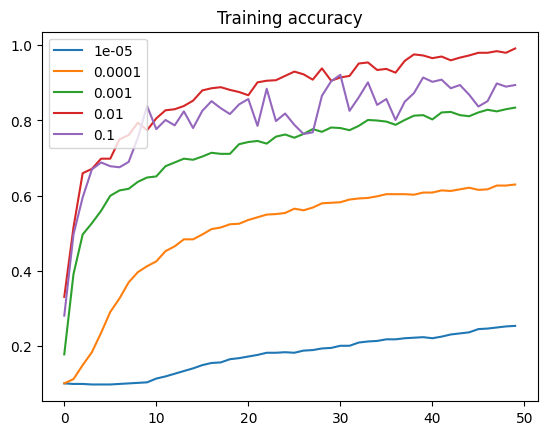

In [49]:
for lr, history in scores.items():
    plt.plot(history["accuracy"], label=lr)

plt.title("Training accuracy")
plt.legend()
plt.show()

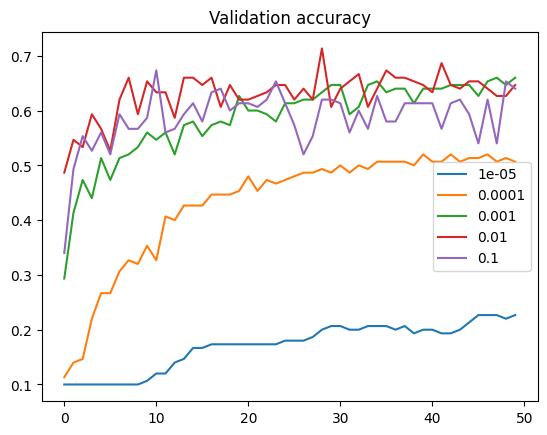

In [50]:
for lr, history in scores.items():
    plt.plot(history["val_accuracy"], label=lr)

plt.title("Validation accuracy")
plt.legend()
plt.show()

In [51]:
#same as used in model Version2
LEARN_RT=0.01

In [53]:
def make_model(inner_sz):
    base_model = MobileNetV2(
        weights="imagenet",
        include_top=False,
        input_shape=IN_SHAPE
    )
    
    base_model.trainable = False

    inputs = keras.Input(shape=IN_SHAPE)
    base = base_model(inputs, training=False)

    #reshape input
    height, width, channels = base.shape[1], base.shape[2], base.shape[3]
    base_reshaped = Reshape((height * width, channels))(base)
    #shape (batch, time, features) so axis=1 to apply it to time
    vectors = AutoPool1D(
        axis=1, 
        kernel_constraint=non_neg(), 
        kernel_regularizer=l2(REG)
    )(base_reshaped)

    inner_layer = Dense(inner_sz, activation=ACTIVATE)(vectors)
    #drop = Dropout(rate=DROP)(inner_layer)

    outputs = Dense(len(GENRES))(inner_layer)
    model = keras.Model(inputs, outputs)

    optimizer = Adam(learning_rate=LEARN_RT)
    loss = CategoricalCrossentropy(from_logits=True)
    
    model.compile(
        optimizer=optimizer,
        loss=loss,
        metrics=[METRIC]
    )

    return model

In [55]:
scores = {}
inner_sizes = [100, 200, 300, 400, 500, 600]

for sz in inner_sizes:
    print(f"Inner size: {sz}")

    model = make_model(sz)
    history = model.fit(X_train_pre, y_train, epochs=EPOCHS, batch_size=BATCH, validation_data=(X_vldtn_pre, y_vldtn))
    scores[sz] = history.history

    print("====")

Inner size: 100


/tmp/ipykernel_1156665/2942012456.py:2: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(


Epoch 1/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 17s 446ms/step - accuracy: 0.2618 - loss: 2.8368 - val_accuracy: 0.3133 - val_loss: 1.8896
Epoch 2/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step - accuracy: 0.4349 - loss: 1.6150 - val_accuracy: 0.4800 - val_loss: 1.5664
Epoch 3/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step - accuracy: 0.5265 - loss: 1.3437 - val_accuracy: 0.4800 - val_loss: 1.5046
Epoch 4/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step - accuracy: 0.5837 - loss: 1.1770 - val_accuracy: 0.5467 - val_loss: 1.2555
Epoch 5/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step - accuracy: 0.6280 - loss: 1.0352 - val_accuracy: 0.5533 - val_loss: 1.2176
Epoch 6/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step - accuracy: 0.6509 - loss: 0.9679 - val_accuracy: 0.5333 - val_loss: 1.2462
Epoch 7/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step - accuracy: 0.6595 - loss: 0.9629 - val_accuracy: 0.5800 - val_loss: 1.1825
Epoch 8/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step - accuracy: 0.6824 - loss: 0.9127 - val_accuracy: 0.5667 -

I0000 00:00:1766535258.262868 2603769 asm_compiler.cc:369] ptxas warning : Registers are spilled to local memory in function 'triton_gemm_dot_1259', 4 bytes spill stores, 4 bytes spill loads



22/22 ━━━━━━━━━━━━━━━━━━━━ 21s 576ms/step - accuracy: 0.2504 - loss: 3.7489 - val_accuracy: 0.3667 - val_loss: 1.7309
Epoch 2/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step - accuracy: 0.4263 - loss: 1.5935 - val_accuracy: 0.4467 - val_loss: 1.5946
Epoch 3/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step - accuracy: 0.5336 - loss: 1.3219 - val_accuracy: 0.4867 - val_loss: 1.3448
Epoch 4/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step - accuracy: 0.6338 - loss: 1.1302 - val_accuracy: 0.5200 - val_loss: 1.2788
Epoch 5/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step - accuracy: 0.6338 - loss: 1.0083 - val_accuracy: 0.5800 - val_loss: 1.1591
Epoch 6/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step - accuracy: 0.6466 - loss: 0.9996 - val_accuracy: 0.5867 - val_loss: 1.2470
Epoch 7/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step - accuracy: 0.6795 - loss: 0.9128 - val_accuracy: 0.6267 - val_loss: 1.1589
Epoch 8/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step - accuracy: 0.7282 - loss: 0.8281 - val_accuracy: 0.6467 - val_loss: 

...

21/22 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.2378 - loss: 6.2685

I0000 00:00:1766535500.434197 2664166 asm_compiler.cc:369] ptxas warning : Registers are spilled to local memory in function 'triton_gemm_dot_1496', 12 bytes spill stores, 12 bytes spill loads

I0000 00:00:1766535500.626910 2664165 asm_compiler.cc:369] ptxas warning : Registers are spilled to local memory in function 'triton_gemm_dot_1496', 264 bytes spill stores, 272 bytes spill loads



22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 266ms/step - accuracy: 0.2392 - loss: 6.1703

I0000 00:00:1766535508.157369 2666128 asm_compiler.cc:369] ptxas warning : Registers are spilled to local memory in function 'triton_gemm_dot_1259', 264 bytes spill stores, 272 bytes spill loads

I0000 00:00:1766535508.417722 2666132 asm_compiler.cc:369] ptxas warning : Registers are spilled to local memory in function 'triton_gemm_dot_1259', 12 bytes spill stores, 12 bytes spill loads



22/22 ━━━━━━━━━━━━━━━━━━━━ 22s 608ms/step - accuracy: 0.2690 - loss: 4.1085 - val_accuracy: 0.3733 - val_loss: 1.7387
Epoch 2/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step - accuracy: 0.5021 - loss: 1.4483 - val_accuracy: 0.4400 - val_loss: 1.5555
Epoch 3/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step - accuracy: 0.5680 - loss: 1.2098 - val_accuracy: 0.5600 - val_loss: 1.3561
Epoch 4/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step - accuracy: 0.6137 - loss: 1.0736 - val_accuracy: 0.5733 - val_loss: 1.2406
Epoch 5/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step - accuracy: 0.6452 - loss: 0.9981 - val_accuracy: 0.6267 - val_loss: 1.1393
Epoch 6/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step - accuracy: 0.6753 - loss: 0.9042 - val_accuracy: 0.5867 - val_loss: 1.1703
Epoch 7/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step - accuracy: 0.6981 - loss: 0.8443 - val_accuracy: 0.6400 - val_loss: 1.0640
Epoch 8/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step - accuracy: 0.7096 - loss: 0.8167 - val_accuracy: 0.6067 - val_loss: 

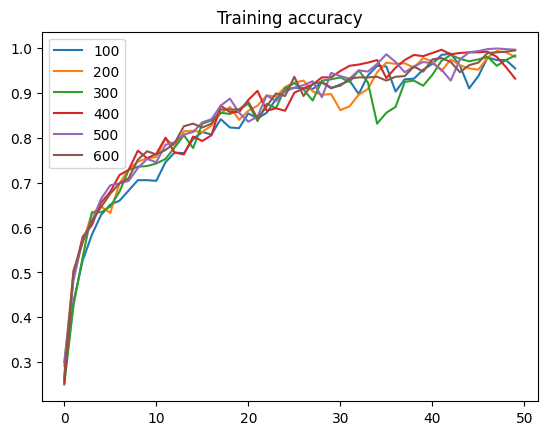

In [56]:
for sz, history in scores.items():
    plt.plot(history["accuracy"], label=sz)

plt.title("Training accuracy")
plt.legend()
plt.show()

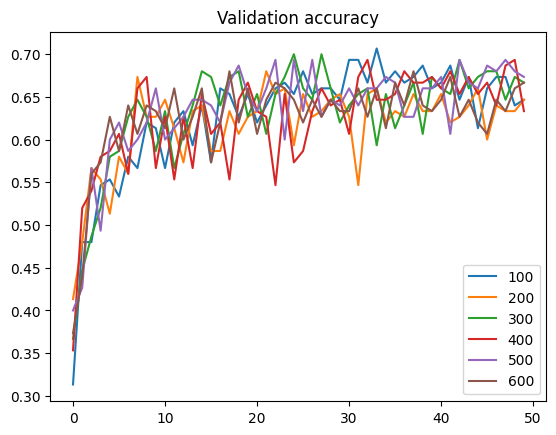

In [57]:
for sz, history in scores.items():
    plt.plot(history["val_accuracy"], label=sz)

plt.title("Validation accuracy")
plt.legend()
plt.show()

In [58]:
scores = {}
inner_sizes = [100, 300, 500]

for sz in inner_sizes:
    print(f"Inner size: {sz}")

    model = make_model(sz)
    history = model.fit(X_train_pre, y_train, epochs=EPOCHS, batch_size=BATCH, validation_data=(X_vldtn_pre, y_vldtn))
    scores[sz] = history.history

    print("====")

Inner size: 100


/tmp/ipykernel_1156665/2942012456.py:2: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(


Epoch 1/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 17s 465ms/step - accuracy: 0.2833 - loss: 2.4067 - val_accuracy: 0.3667 - val_loss: 1.7536
Epoch 2/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step - accuracy: 0.4378 - loss: 1.5267 - val_accuracy: 0.4800 - val_loss: 1.4676
Epoch 3/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step - accuracy: 0.5308 - loss: 1.3071 - val_accuracy: 0.4600 - val_loss: 1.4556
Epoch 4/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step - accuracy: 0.6094 - loss: 1.1441 - val_accuracy: 0.5400 - val_loss: 1.2806
Epoch 5/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step - accuracy: 0.6381 - loss: 1.0308 - val_accuracy: 0.5400 - val_loss: 1.1928
Epoch 6/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step - accuracy: 0.6624 - loss: 0.9504 - val_accuracy: 0.6133 - val_loss: 1.1299
Epoch 7/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step - accuracy: 0.6924 - loss: 0.8718 - val_accuracy: 0.6067 - val_loss: 1.1171
Epoch 8/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step - accuracy: 0.7096 - loss: 0.8204 - val_accuracy: 0.5933 -

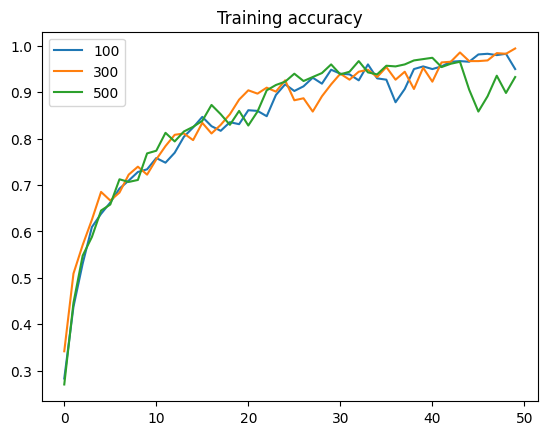

In [59]:
for sz, history in scores.items():
    plt.plot(history["accuracy"], label=sz)

plt.title("Training accuracy")
plt.legend()
plt.show()

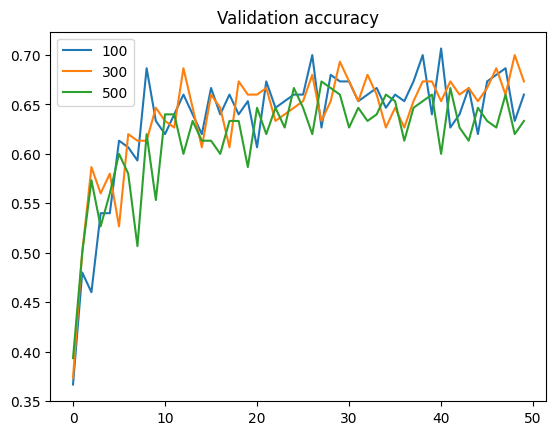

In [60]:
for sz, history in scores.items():
    plt.plot(history["val_accuracy"], label=sz)

plt.title("Validation accuracy")
plt.legend()
plt.show()

In [61]:
INN_SZ=100

In [62]:
def make_model(drop):
    base_model = MobileNetV2(
        weights="imagenet",
        include_top=False,
        input_shape=IN_SHAPE
    )
    
    base_model.trainable = False

    inputs = keras.Input(shape=IN_SHAPE)
    base = base_model(inputs, training=False)

    #reshape input
    height, width, channels = base.shape[1], base.shape[2], base.shape[3]
    base_reshaped = Reshape((height * width, channels))(base)
    #shape (batch, time, features) so axis=1 to apply it to time
    vectors = AutoPool1D(
        axis=1, 
        kernel_constraint=non_neg(), 
        kernel_regularizer=l2(REG)
    )(base_reshaped)

    inner_layer = Dense(INN_SZ, activation=ACTIVATE)(vectors)
    drop = Dropout(rate=drop)(inner_layer)

    outputs = Dense(len(GENRES))(drop)
    model = keras.Model(inputs, outputs)

    optimizer = Adam(learning_rate=LEARN_RT)
    loss = CategoricalCrossentropy(from_logits=True)
    
    model.compile(
        optimizer=optimizer,
        loss=loss,
        metrics=[METRIC]
    )

    return model

In [63]:
scores = {}
drop_rates = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6]

for dr in drop_rates:
    print(f"Drop rate: {dr}")

    model = make_model(dr)
    history = model.fit(X_train_pre, y_train, epochs=EPOCHS, batch_size=BATCH, validation_data=(X_vldtn_pre, y_vldtn))
    scores[dr] = history.history

    print("====")

Drop rate: 0.0


/tmp/ipykernel_1156665/2043074183.py:2: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(


Epoch 1/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 15s 361ms/step - accuracy: 0.2389 - loss: 3.0139 - val_accuracy: 0.3533 - val_loss: 1.8223
Epoch 2/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step - accuracy: 0.4621 - loss: 1.5638 - val_accuracy: 0.4667 - val_loss: 1.4846
Epoch 3/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step - accuracy: 0.5351 - loss: 1.3446 - val_accuracy: 0.5400 - val_loss: 1.2856
Epoch 4/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step - accuracy: 0.5751 - loss: 1.1598 - val_accuracy: 0.5667 - val_loss: 1.2942
Epoch 5/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step - accuracy: 0.6266 - loss: 1.0386 - val_accuracy: 0.5600 - val_loss: 1.2312
Epoch 6/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step - accuracy: 0.6624 - loss: 0.9706 - val_accuracy: 0.6000 - val_loss: 1.1701
Epoch 7/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step - accuracy: 0.6981 - loss: 0.8606 - val_accuracy: 0.6000 - val_loss: 1.1202
Epoch 8/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step - accuracy: 0.7124 - loss: 0.8327 - val_accuracy: 0.6000 -

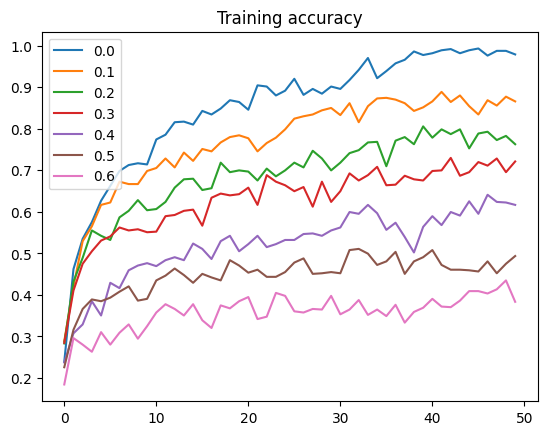

In [64]:
for dr, history in scores.items():
    plt.plot(history["accuracy"], label=dr)

plt.title("Training accuracy")
plt.legend()
plt.show()

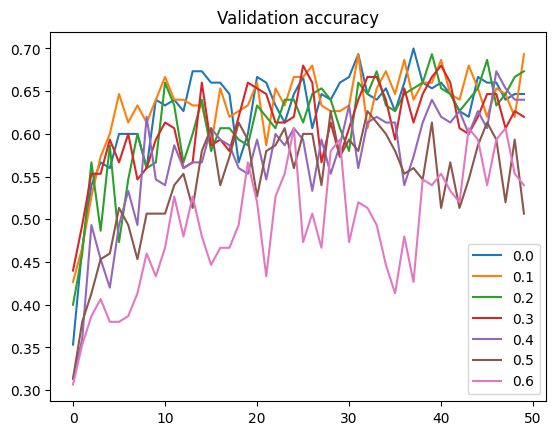

In [65]:
for dr, history in scores.items():
    plt.plot(history["val_accuracy"], label=dr)

plt.title("Validation accuracy")
plt.legend()
plt.show()

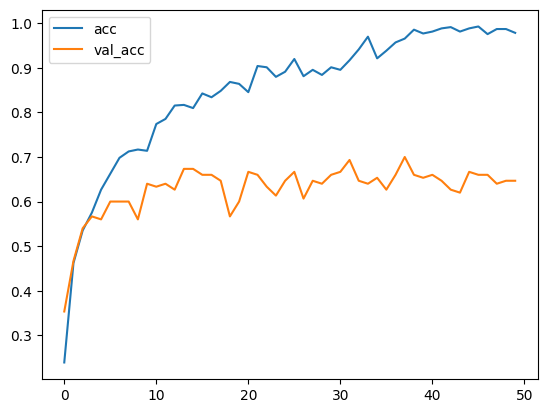

In [66]:
hist = scores[0.0]
plt.plot(hist["accuracy"], label="acc")
plt.plot(hist["val_accuracy"], label="val_acc")
plt.legend()
plt.show()

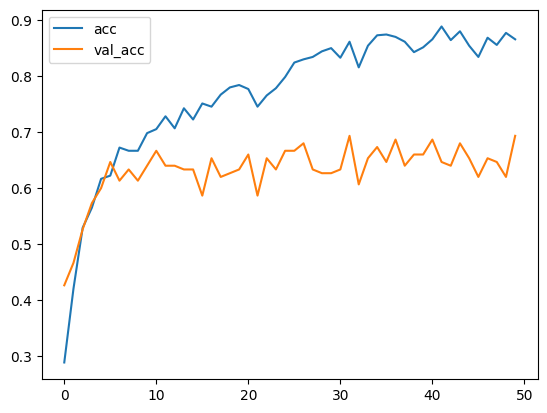

In [67]:
hist = scores[0.1]
plt.plot(hist["accuracy"], label="acc")
plt.plot(hist["val_accuracy"], label="val_acc")
plt.legend()
plt.show()

In this case using regularization explicitly through dropout does not help to increase performance

In [68]:
DROP=0.0

In [69]:
checkpoint = ModelCheckpoint(
    "../models/mobilenetv2_v5_ms1_{epoch:02d}_val_acc_{val_accuracy:.3f}.keras",
    save_best_only=True,
    monitor="val_accuracy",
    mode="max"
)

In [70]:
def make_model():
    base_model = MobileNetV2(
        weights="imagenet",
        include_top=False,
        input_shape=IN_SHAPE
    )
    
    base_model.trainable = False

    inputs = keras.Input(shape=IN_SHAPE)
    base = base_model(inputs, training=False)

    #reshape input
    height, width, channels = base.shape[1], base.shape[2], base.shape[3]
    base_reshaped = Reshape((height * width, channels))(base)
    #shape (batch, time, features) so axis=1 to apply it to time
    vectors = AutoPool1D(
        axis=1, 
        kernel_constraint=non_neg(), 
        kernel_regularizer=l2(REG)
    )(base_reshaped)

    inner_layer = Dense(INN_SZ, activation=ACTIVATE)(vectors)
    drop = Dropout(rate=DROP)(inner_layer)

    outputs = Dense(len(GENRES))(drop)
    model = keras.Model(inputs, outputs)

    optimizer = Adam(learning_rate=LEARN_RT)
    loss = CategoricalCrossentropy(from_logits=True)
    
    model.compile(
        optimizer=optimizer,
        loss=loss,
        metrics=[METRIC]
    )

    return model

In [71]:
model = make_model()

history = model.fit(
    X_train_pre, 
    y_train, 
    epochs=EPOCHS, 
    batch_size=BATCH, 
    validation_data=(X_vldtn_pre, y_vldtn),
    callbacks=[checkpoint]
)

/tmp/ipykernel_1156665/1488313765.py:2: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(


Epoch 1/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 15s 397ms/step - accuracy: 0.3033 - loss: 2.1908 - val_accuracy: 0.4333 - val_loss: 1.5396
Epoch 2/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 74ms/step - accuracy: 0.5179 - loss: 1.4198 - val_accuracy: 0.5333 - val_loss: 1.3982
Epoch 3/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step - accuracy: 0.5994 - loss: 1.1304 - val_accuracy: 0.4933 - val_loss: 1.3371
Epoch 4/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step - accuracy: 0.6166 - loss: 1.1081 - val_accuracy: 0.5333 - val_loss: 1.3105
Epoch 5/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 72ms/step - accuracy: 0.6681 - loss: 0.9494 - val_accuracy: 0.6467 - val_loss: 1.1253
Epoch 6/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step - accuracy: 0.6981 - loss: 0.8604 - val_accuracy: 0.5800 - val_loss: 1.1990
Epoch 7/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step - accuracy: 0.7339 - loss: 0.8277 - val_accuracy: 0.6267 - val_loss: 1.1577
Epoch 8/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step - accuracy: 0.7310 - loss: 0.7707 - val_accuracy: 0.5867 -

After trying a few approaches the best model achieved 0.70 validation accuracy from previous 0.615 which is a good improvement for a simple model.

I can try other parameters mostly for mel spectrogram data, as the rectangular shape combined with square weights of MobileNetV2 yield a better result
than using square shaped data all along and of course standard mel spectrogram parameters and AutoPool.